# Create_Sign

In [ ]:
###############

# Collage_Labelling

In [67]:
import sys
sys.path.append("CollageLabelling")

import importlib
import CollageLabelling
importlib.reload(CollageLabelling)

from CollageLabelling import Image_Merger_Labelling
from CollageLabelling import Label_Img
from CollageLabelling import Background_Img

In [68]:
bg_path = "./Resource/IMG_background/BG_1.jpg"
bg = Background_Img(bg_path)

lb_1 = "./Resource/IMG_label/tron_1.jpg"
lb_2 = "./Resource/IMG_label/tam_giac_1.png"
lb_3 = "./Resource/IMG_label/vuong_1.png"
lb_list = [Label_Img(lb_1, 'tron'),
           Label_Img(lb_2, 'tam_giac'),
           Label_Img(lb_3, 'vuong')]

tool = Image_Merger_Labelling(lb_list, bg)

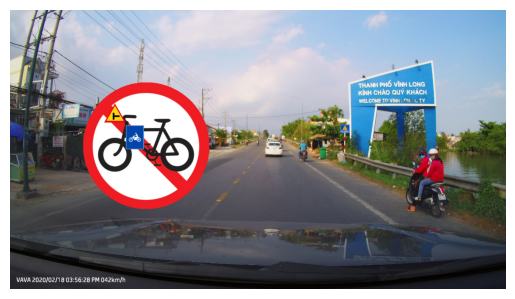

In [69]:
tool.ShowMerge()

In [70]:
tool.Auto_Labelling("./", "test_1", "0")

0

In [ ]:
import cv2

image_path = "./Resource/IMG_background/BG_1.jpg"  # Đường dẫn đến ảnh
image = cv2.imread(image_path)
H, W, _ = image.shape  # Lấy kích thước ảnh

# Đọc file nhãn YOLO
label_path = "./test_1.txt"  # File YOLO label
with open(label_path, "r") as file:
    lines = file.readlines()

# Duyệt qua từng dòng trong file nhãn
for line in lines:
    data = line.strip().split()
    class_id = int(data[0])  # Lớp của đối tượng
    x_center, y_center, width, height = map(float, data[1:])

    # Chuyển đổi tọa độ YOLO sang pixel
    xmin = int((x_center - width / 2) * W)
    ymin = int((y_center - height / 2) * H)
    xmax = int((x_center + width / 2) * W)
    ymax = int((y_center + height / 2) * H)

    # Vẽ bounding box lên ảnh
    color = (0, 255, 0)  # Màu xanh lá
    thickness = 2
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)

    # Hiển thị nhãn class_id trên bounding box
    label = f"Class {class_id}"
    cv2.putText(image, label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Hiển thị ảnh
# cv2.imshow("YOLO Bounding Box", image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Lưu ảnh có bounding box
cv2.imwrite("output.jpg", image)


True